In [1]:
import calendar
from datetime import timedelta, datetime
import pprint

import ee
from IPython.display import Image, display
import ipyplot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import openet.core

ee.Initialize()

In [2]:
filled_coll = ee.ImageCollection('projects/openet/assets/ensemble/conus/gridmet/monthly/v2_1_filled')

region = [-125, 25, -66.5, 50]

et_palette = [
    'DEC29B', 'E6CDA1', 'EDD9A6', 'F5E4A9', 'FFF4AD', 'C3E683', '6BCC5C', 
    '3BB369', '20998F', '1C8691', '16678A', '114982', '0B2C7A'
]
viridis = ['440154', '433982', '30678D', '218F8B', '36B677', '8ED542', 'FDE725']
et_vis = {'min': 0, 'max': 150, 'palette': et_palette}
mask_vis = {'min': 0, 'max': 3, 'palette': viridis}

dates = [f'{year:04d}-{month:02d}-01' for year in [2024] for month in range(1, 13)]

image_size = 900

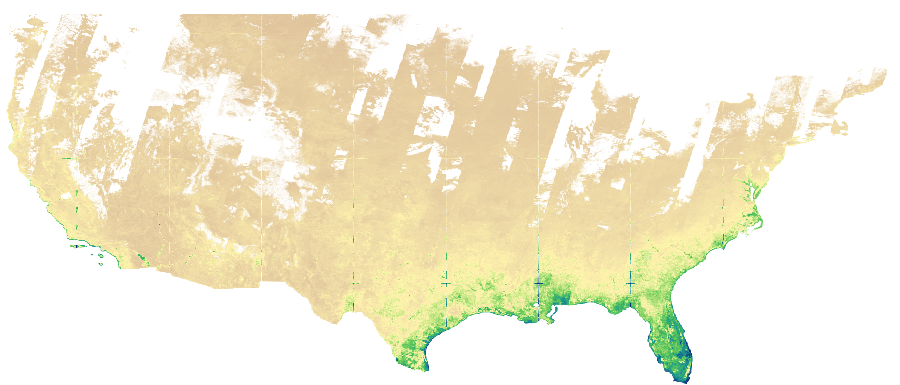

In [3]:
date = '2024-01-01'
et_vis = {'min': 0, 'max': 100, 'palette': et_palette}
Image(
    filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['et_unfilled']).sum().visualize(**et_vis)
        .getThumbURL({'region': region, 'dimensions': image_size}), 
    embed=True, format='png'
)

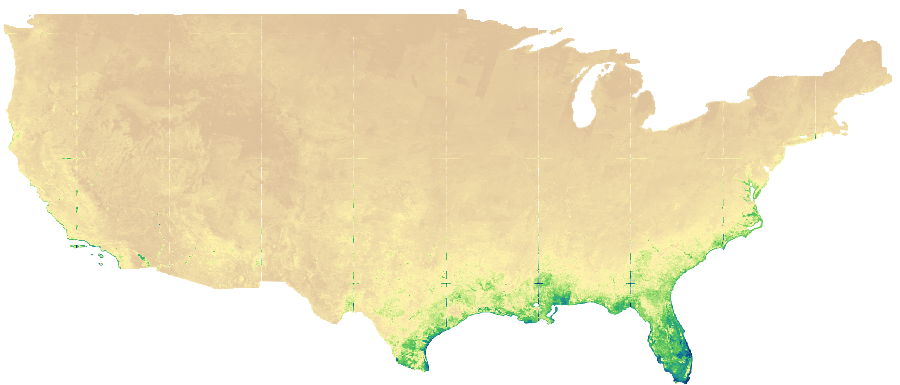

In [4]:
date = '2024-01-01'
et_vis = {'min': 0, 'max': 100, 'palette': et_palette}
Image(
    filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['et_filled']).sum().visualize(**et_vis)
        .getThumbURL({'region': region, 'dimensions': image_size}), 
    embed=True, format='png'
)

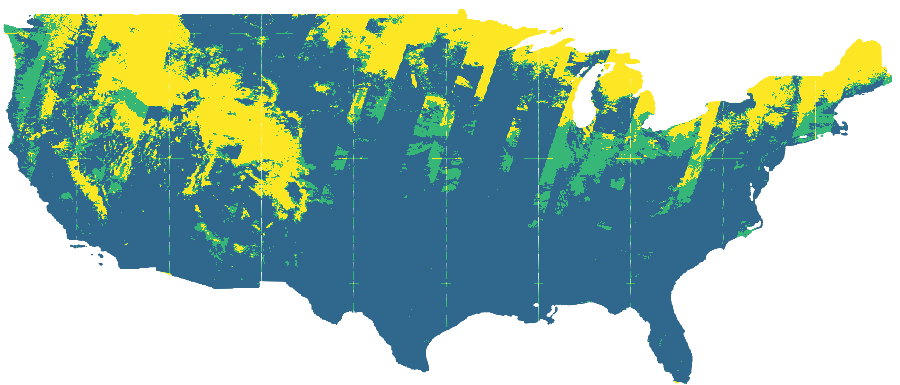

In [5]:
date = '2024-01-01'
Image(
    filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['filled_mask']).sum().visualize(**mask_vis)
        .getThumbURL({'region': region, 'dimensions': image_size}), 
    embed=True, format='png'
)

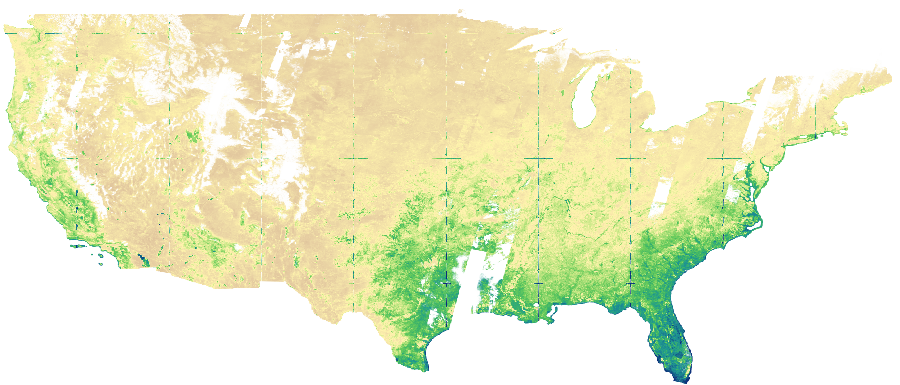

In [6]:
date = '2024-03-01'
et_vis = {'min': 0, 'max': 150, 'palette': et_palette}
Image(
    filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['et_unfilled']).sum().visualize(**et_vis)
        .getThumbURL({'region': region, 'dimensions': image_size}), 
    embed=True, format='png'
)

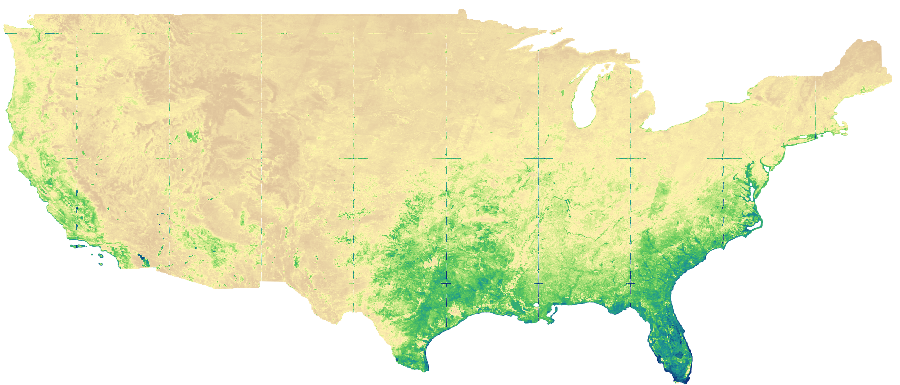

In [7]:
date = '2024-03-01'
et_vis = {'min': 0, 'max': 150, 'palette': et_palette}
Image(
    filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['et_filled']).sum().visualize(**et_vis)
        .getThumbURL({'region': region, 'dimensions': image_size}), 
    embed=True, format='png'
)

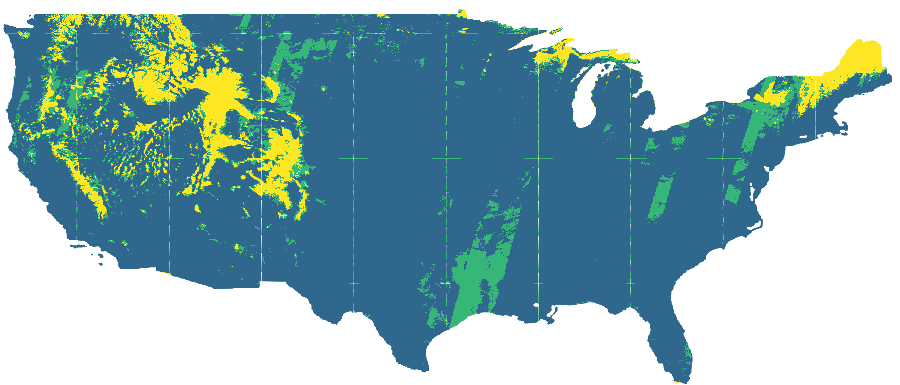

In [8]:
date = '2024-03-01'
Image(
    filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['filled_mask']).sum().visualize(**mask_vis)
        .getThumbURL({'region': region, 'dimensions': image_size}), 
    embed=True, format='png'
)

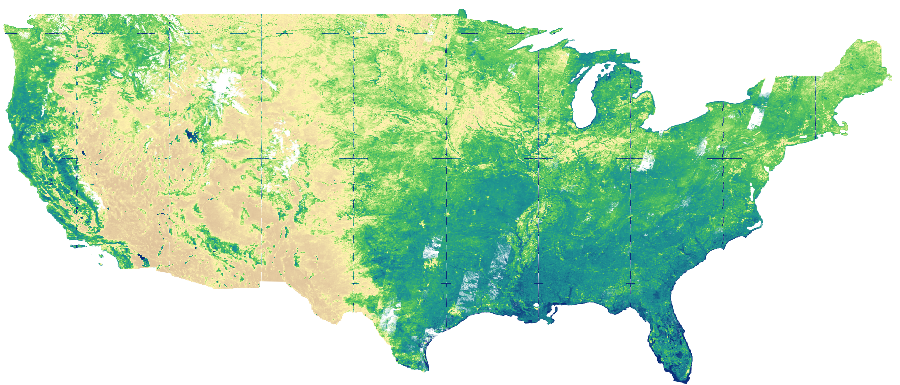

In [9]:
date = '2024-05-01'
et_vis = {'min': 0, 'max': 200, 'palette': et_palette}
Image(
    filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['et_unfilled']).sum().visualize(**et_vis)
        .getThumbURL({'region': region, 'dimensions': image_size}), 
    embed=True, format='png'
)

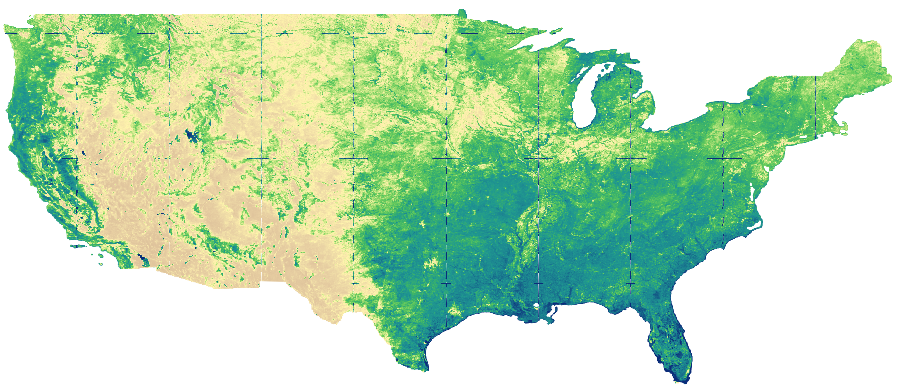

In [10]:
date = '2024-05-01'
et_vis = {'min': 0, 'max': 200, 'palette': et_palette}
Image(
    filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['et_filled']).sum().visualize(**et_vis)
        .getThumbURL({'region': region, 'dimensions': image_size}), 
    embed=True, format='png'
)

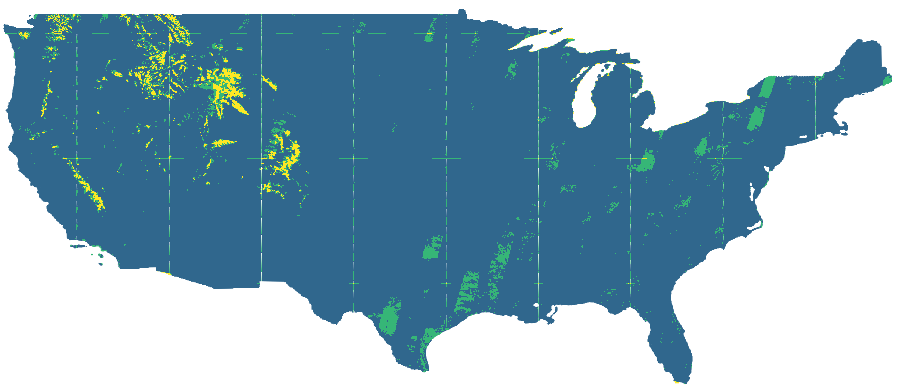

In [11]:
date = '2024-05-01'
Image(
    filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['filled_mask']).sum().visualize(**mask_vis)
        .getThumbURL({'region': region, 'dimensions': image_size}), 
    embed=True, format='png'
)

In [12]:
urls = []
labels = []
for date in dates:
    image_url = (
        filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['et_unfilled']).sum()
        .visualize(**et_vis).getThumbURL({'region': region, 'dimensions': image_size})
    )
    urls.append(image_url)
    labels.append(f'Unfilled Ensemble ET {date}')
        
ipyplot.plot_images(urls, labels=labels, show_url=False, img_width=image_size)

In [13]:
image_size = 1000
urls = []
labels = []
for date in dates:
    image_url = (
        filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['et_filled']).sum()
        .visualize(**et_vis).getThumbURL({'region': region, 'dimensions': image_size})
    )
    urls.append(image_url)
    labels.append(f'Filled Ensemble ET {date}')
        
ipyplot.plot_images(urls, labels=labels, show_url=False, img_width=image_size)

In [14]:
urls = []
labels = []
for date in dates:
    image_url = (
        filled_coll.filterDate(ee.Date(date), ee.Date(date).advance(1, 'month'))
        .select(['filled_mask']).mean()
        .visualize(**mask_vis).getThumbURL({'region': region, 'dimensions': image_size})
    )
    urls.append(image_url)
    labels.append(f'Filled Ensemble Mask {date}')
    
ipyplot.plot_images(urls, labels=labels, show_url=False, img_width=image_size)